<a href="https://colab.research.google.com/github/ansarione/FoodHub/blob/main/FoodHub_EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read the data
# define the path
path = "/content/drive/MyDrive/Project_Foodhub/foodhub_order.csv"

# load the data
df = pd.read_csv(path)

In [ ]:
# Output the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# check and print the shape of the data
print("There are", df.shape[0], 'rows and', df.shape[1], "columns.")

There are 1898 rows and 9 columns.


#### Observations:

#### There are **1898 rows** and **9 columns** in this dataset

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use .info() function to view the data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

####  

*   Categorical variables include:

    1.   restaurant_name
    2.   cuisine_type
    3.   day_of_the_week


*   Numerical variables include:

    1. order_id
    2. customer_id
    3. cost_of_the_order
    4. food_preparation_time
    5. delivery_time
*   **rating variable:**
  *   There are two approaches to handle the rating variable.
  *   *Approach-1:* There are 736 customers who did not provide a rating. This represents a lack of feedback from the users rather than a missing data error. Consequently, the 'rating' variable will not be converted to float64, and 'Not Given' will be treated as a distinct categorical value.
  *   *Approach-2:* The rating variable originally contained the value "Not given" for 736 orders, indicating that customers did not provide feedback. These entries will be treated as missing values in the next Question and converted to NaN to allow proper numerical analysis. The column was then converted to float64.



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Create a copy (backup) of original rating column
df['rating_original'] = df['rating'].copy()

# Use panda function .to_numeric to convert rating column from object to float64
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [ ]:
# Check now for the missing values
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0
rating_original,0


In [ ]:
# Calculate the percentage of missing values in rating column
missing_percentage = (df['rating'].isnull().sum() / len(df)) * 100
print(f"The percentage of missing values in the 'rating' column is: {missing_percentage:.2f}%")

The percentage of missing values in the 'rating' column is: 38.78%


#### Observations:

1. The rating variable originally contained the value "Not given" for 736 orders, indicating that customers did not provide feedback. Moreover the datatype of 'rating' is an Object, it is converted to float64.

2. There are 38.78% of missing values which is a significant number and these rows cannot be dropped.

3. The missing ratings may not be random and could introduce bias if customers who had extreme experiences (very good or very bad) are more likely to leave ratings. This should be considered in further analysis.

4. Since the absence of a rating does not imply a neutral score, no imputation was performed during exploratory analysis.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# The overall statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
rating,1162.0,4.344234e+00,0.741478,3.00,4.00,5.00,5.000000e+00,5.00
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [ ]:
# Minimum time to prepare the food
min_food_prep_time = df['food_preparation_time'].min()

# Average time to prepare the food
avg_food_prep_time = df['food_preparation_time'].mean()

# Maximum time to prepare the food
max_food_prep_time = df['food_preparation_time'].max()


print ('The Minimum food preperation time is ', min_food_prep_time, 'Minutes')
print ('The Average food preperation time is ', round(avg_food_prep_time,2), 'Minutes')
print ('The Maximum food preperation time is ', max_food_prep_time, 'Minutes')

The Minimum food preperation time is  20 Minutes
The Average food preperation time is  27.37 Minutes
The Maximum food preperation time is  35 Minutes


#### Observations:

The Minimum food preperation time is  **20 Minutes**

The Average food preperation time is  **27.37 Minutes**

The Maximum food preperation time is  **35 Minutes**

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Check how many unique values are there in rating column
df['rating'].unique()


array([nan,  5.,  3.,  4.])

In [ ]:
# Check the rating column for NaN values
df['rating'].isnull().sum()

np.int64(736)

In [ ]:
# Additionally calculate the % age of orders with Rating as Not Given
df['rating'].isnull().sum() / len(df) * 100

np.float64(38.77766069546891)

#### Observations:
A total of **736** Orders are **Not rated** which comprises about **38.78%** of overall orders

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### Order ID

In [ ]:
# Check and print unique Orders
print ('Total number of received Orders are', df['order_id'].nunique())

Total number of received Orders are 1898


##### Observations:
A total of **1898** Orders are received and fulfilled

#### Customer ID

In [ ]:
# Check and print Customer IDs
print ('There are Total', df['customer_id'].nunique(), 'Registered Customers of Foodhub')

There are Total 1200 Registered Customers of Foodhub


##### Observations:
There are Total **1200** Registered Customers of Foodhub

#### Restaurant Name

In [ ]:
# Check and print Restaurant Names
print ('There are Total', df['restaurant_name'].nunique(), 'Restaurants Registered with Foodhub')

There are Total 178 Restaurants Registered with Foodhub


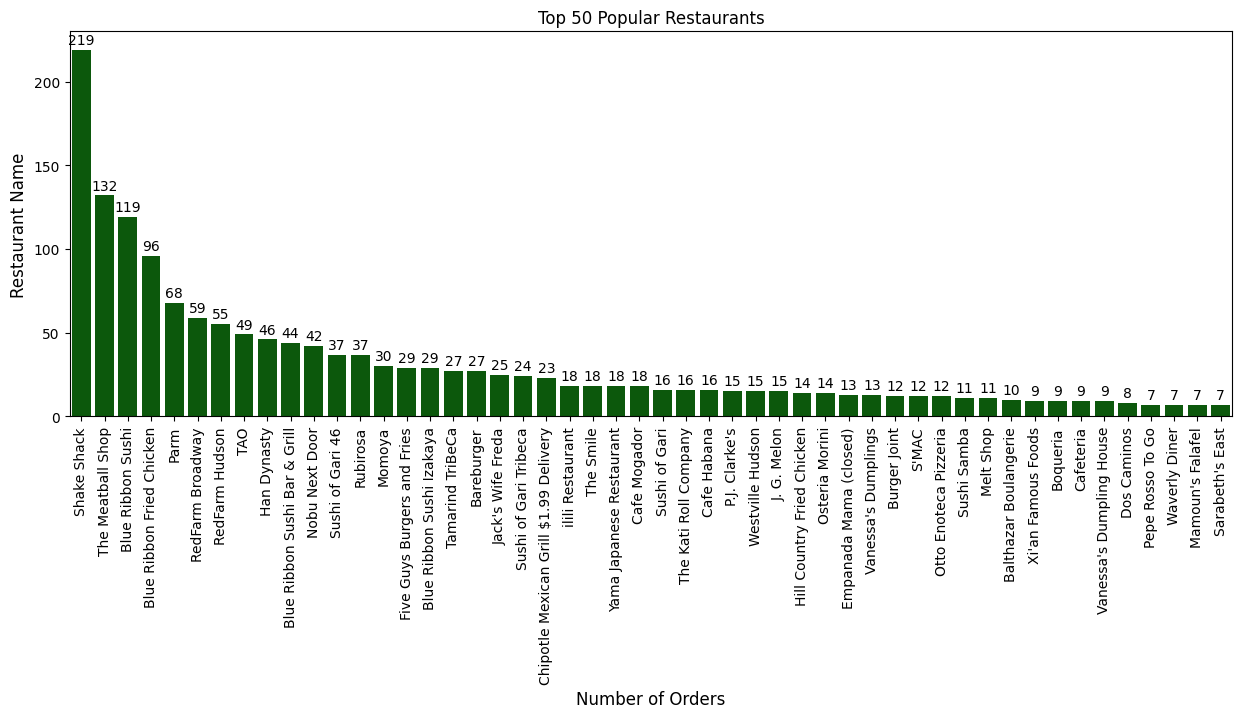

In [ ]:
# Check the top 15 restaurants sorted by the number of orders by each.
plt.figure(figsize=(15,5));
rst = sns.countplot(data=df, x='restaurant_name', color='darkgreen', order=df['restaurant_name'].value_counts().head(50).index);
rst.bar_label(rst.containers[0], padding=2)
plt.xticks(rotation=90);
plt.title('Top 50 Popular Restaurants')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=12)
plt.show()

##### Observations:
There are Total **178** Restaurants registered with Foodhub. Some restaurants are more popular than others.

#### Cusine Type

In [ ]:
# Check and print Cusine Type
print ('There are ', df['cuisine_type'].nunique(), 'Different Types of Cuisines available in ', df['restaurant_name'].nunique(), 'Restaurants')

There are  14 Different Types of Cuisines available in  178 Restaurants


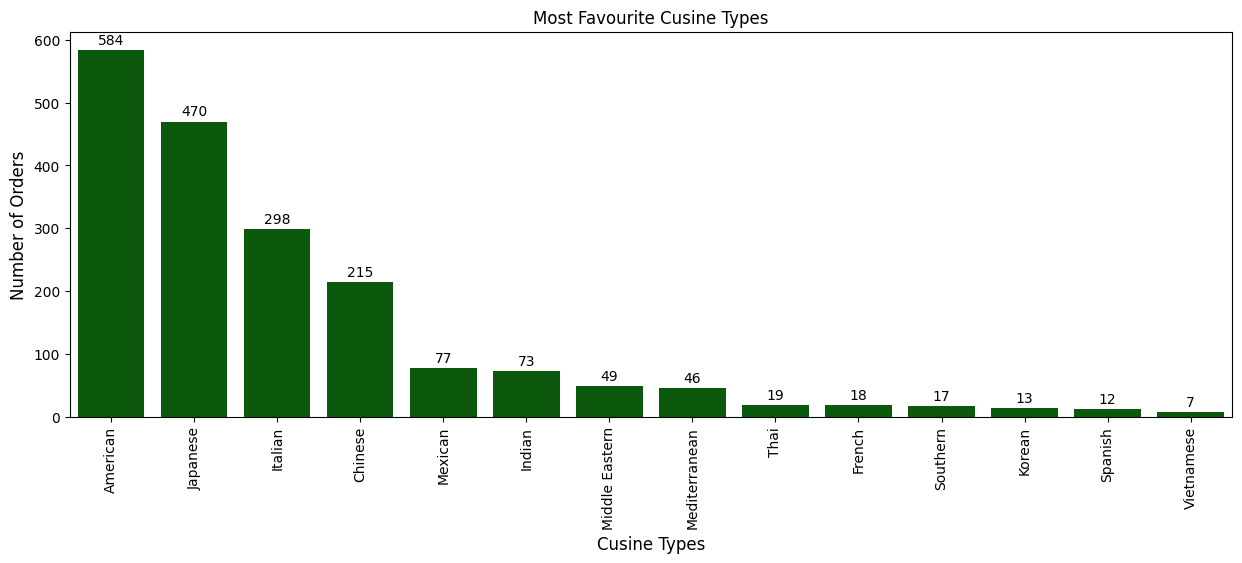

In [ ]:
# Histogram of cuisine_type:
plt.figure(figsize=(15,5));
cst = sns.countplot(data=df, x='cuisine_type', color='darkgreen', order=df['cuisine_type'].value_counts().index);
plt.xticks(rotation=90);
cst.bar_label(cst.containers[0], padding=2)
plt.xticks(rotation=90);
plt.title('Most Favourite Cusine Types')
plt.xlabel('Cusine Types', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()

##### Observations:
* There are  **14** Different Types of Cuisines available in  **178** Restaurants.
* American cuisine is the most popular, followed by Japanese, Italian and Chinese.
* Korean, Spanish and Vietnamese cuisines are giving less business, highlighting the opportunities for marketing, food variety and overall quality.

#### Cost of the Order

In [ ]:
# Statistical distribution of the Cost of the Order
df['cost_of_the_order'].describe().T

,cost_of_the_order
count,1898.000000
mean,16.498851
std,7.483812
min,4.470000
25%,12.080000
50%,14.140000
75%,22.297500
max,35.410000


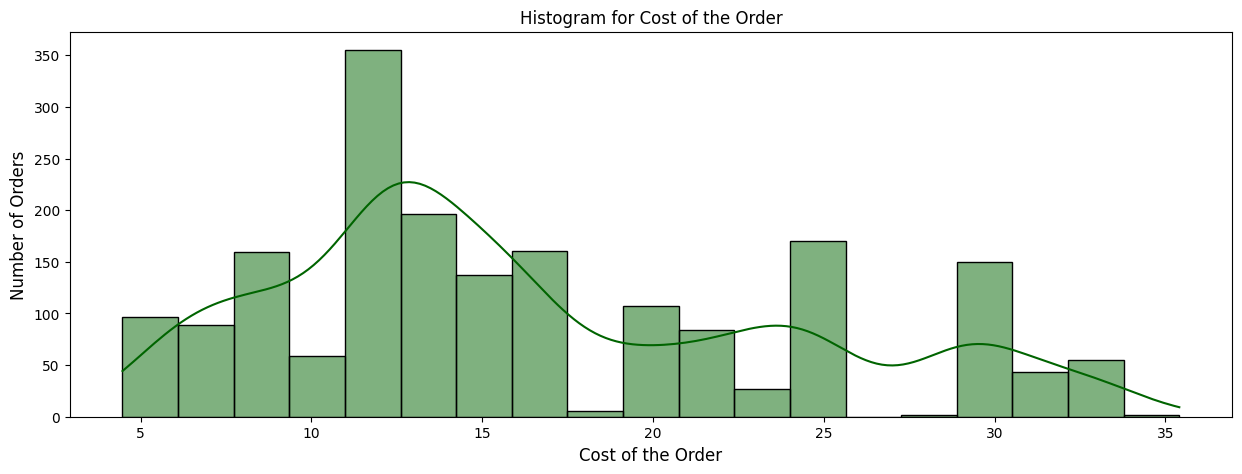

In [ ]:
# Histogram for the cost of order
plt.figure(figsize=(15,5));
sns.histplot(data=df,x='cost_of_the_order', kde=True, color='darkgreen');
plt.title('Histogram for Cost of the Order')
plt.xlabel('Cost of the Order', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()

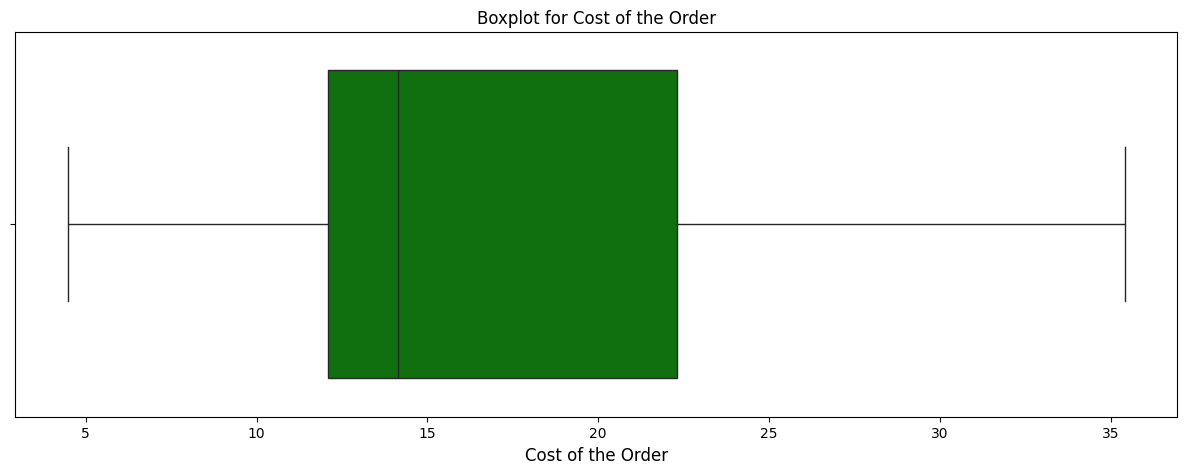

In [ ]:
# Boxplot for the cost of order
plt.figure(figsize=(15,5));
sns.boxplot(data=df,x='cost_of_the_order', color='green')
plt.title('Boxplot for Cost of the Order')
plt.xlabel('Cost of the Order', fontsize=12)
plt.show()

##### Observations:
* The Average Cost of the Order is 16.49 dollars, while minimum is 4.47 dollars and maximum is 35.4 dollars.
* The Histogram and Boxplot plots show that data is right (positive) skewed.
* More than 75% of orders cost less than 22.3 dollars

#### Day of the Week

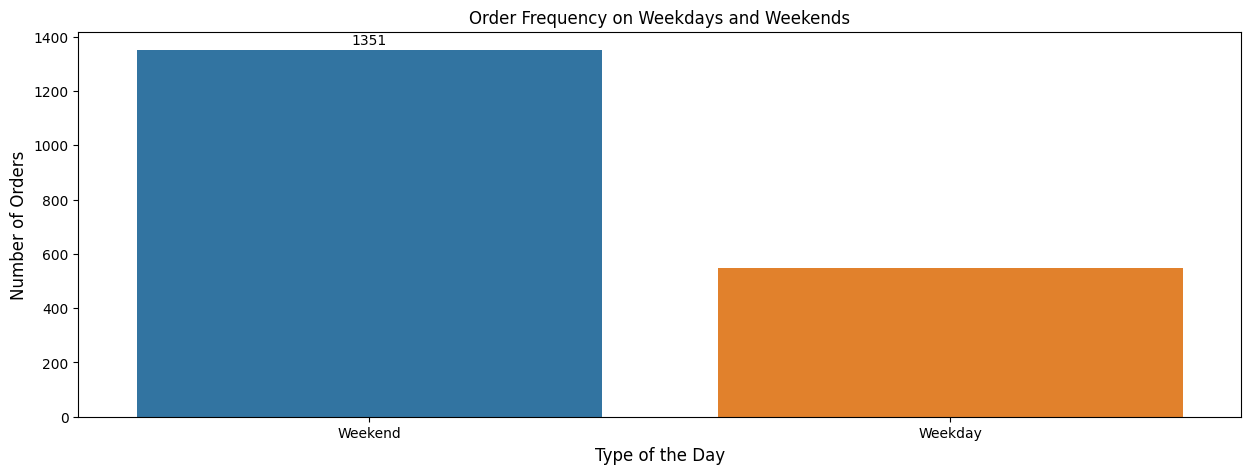

In [ ]:
# Check Order frequency on weekdays and weekends
plt.figure(figsize=(15,5));
dow = sns.countplot(data=df, x='day_of_the_week', hue='day_of_the_week');
dow.bar_label(dow.containers[0], padding=2)
plt.title('Order Frequency on Weekdays and Weekends');
plt.xlabel('Type of the Day', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()


##### Observations:
* The Countplot shows that most orders are received on weekend compared to weekdays.
* 1351 Orders received on weekends with less than half 547 orders on weekdays.

#### Rating

In [ ]:
# Check the unique values of rating
df['rating'].unique()

array([None], dtype=object)

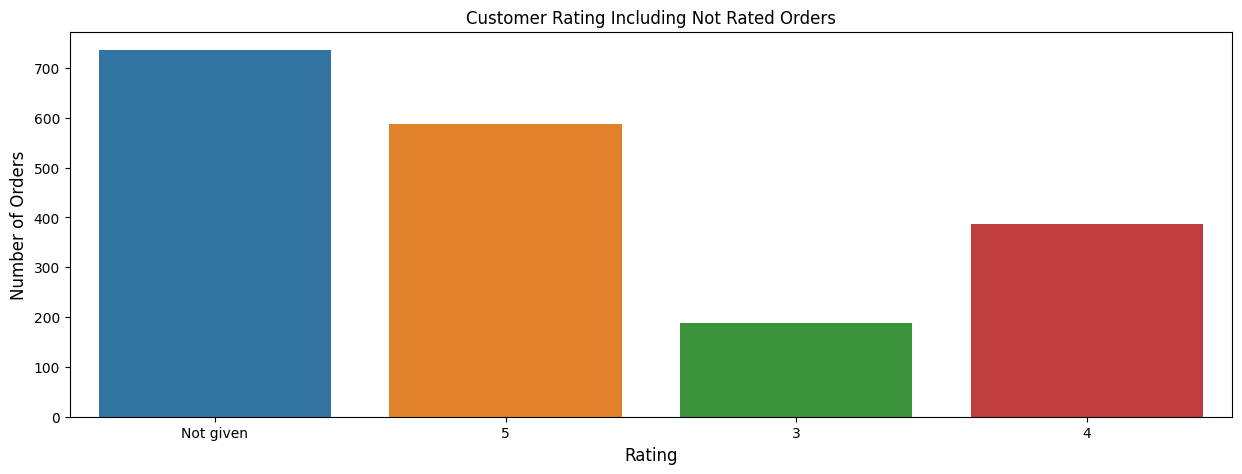

In [ ]:
# Plot the customer rating on a bar graph
plt.figure(figsize=(15,5));
sns.countplot(data=df, x='rating_original', hue='rating_original', legend=False);
plt.title('Customer Rating Including Not Rated Orders')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()

##### Observations:
* The rating plot shows most customers are satisfied and give positive rating

#### Food Preparation Time

In [ ]:
# Statistically explore Food preparation time
df['food_preparation_time'].describe().T

,food_preparation_time
count,1898.000000
mean,27.371970
std,4.632481
min,20.000000
25%,23.000000
50%,27.000000
75%,31.000000
max,35.000000


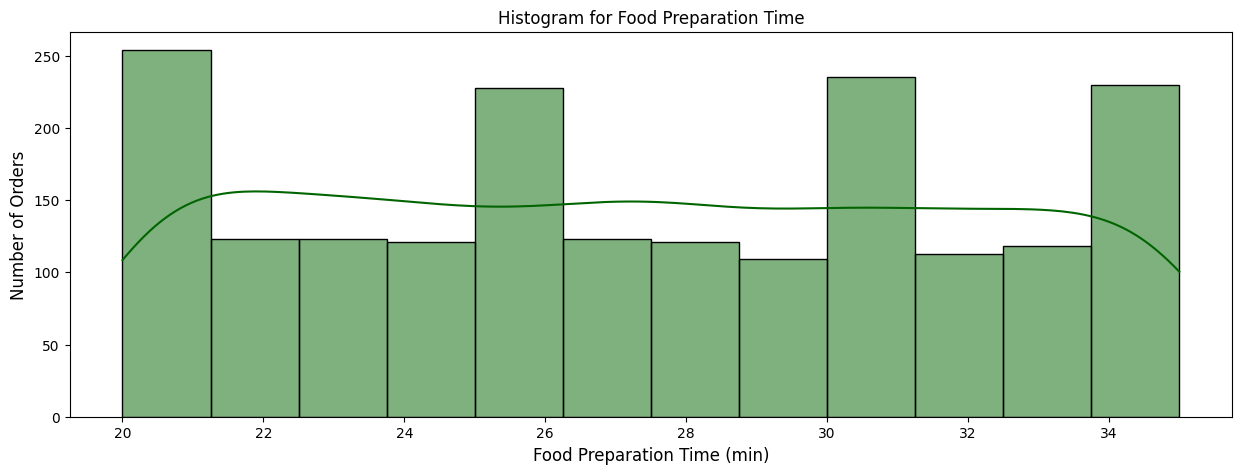

In [ ]:
# Check the trend of Food preparation time using the Histogram to get more insight
plt.figure(figsize=(15,5));
sns.histplot(data=df,x='food_preparation_time', kde=True, color='darkgreen');
plt.title('Histogram for Food Preparation Time')
plt.xlabel('Food Preparation Time (min)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()

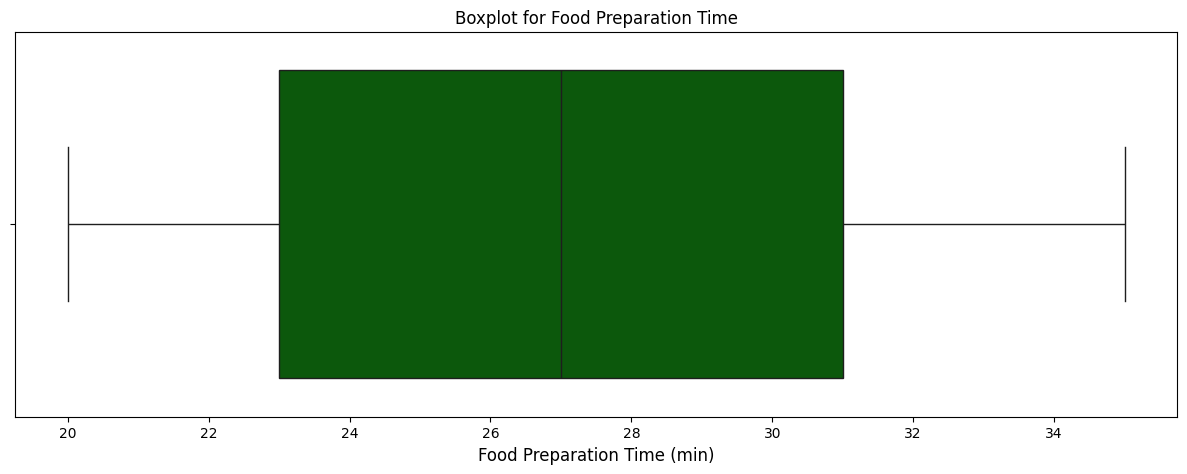

In [ ]:
# Let us see the Box plot for Food preparation time
plt.figure(figsize=(15,5));
sns.boxplot(data=df,x='food_preparation_time', color='darkgreen')
plt.title('Boxplot for Food Preparation Time')
plt.xlabel('Food Preparation Time (min)', fontsize=12)
plt.show()


##### Observations:
* The plots show the average time taken for Food preparation is between **23 to 31 minutes**. While some foods take longer up to 35 minutes.
* As there are no outliers in the Box plot, this also shows that most restaurants follow a streamlined process to prepare food, which is also reflected in the positive customer rating.

#### Delivery Times

In [ ]:
# Statistically explore the Delivery time column
df['delivery_time'].describe().T

,delivery_time
count,1898.000000
mean,24.161749
std,4.972637
min,15.000000
25%,20.000000
50%,25.000000
75%,28.000000
max,33.000000


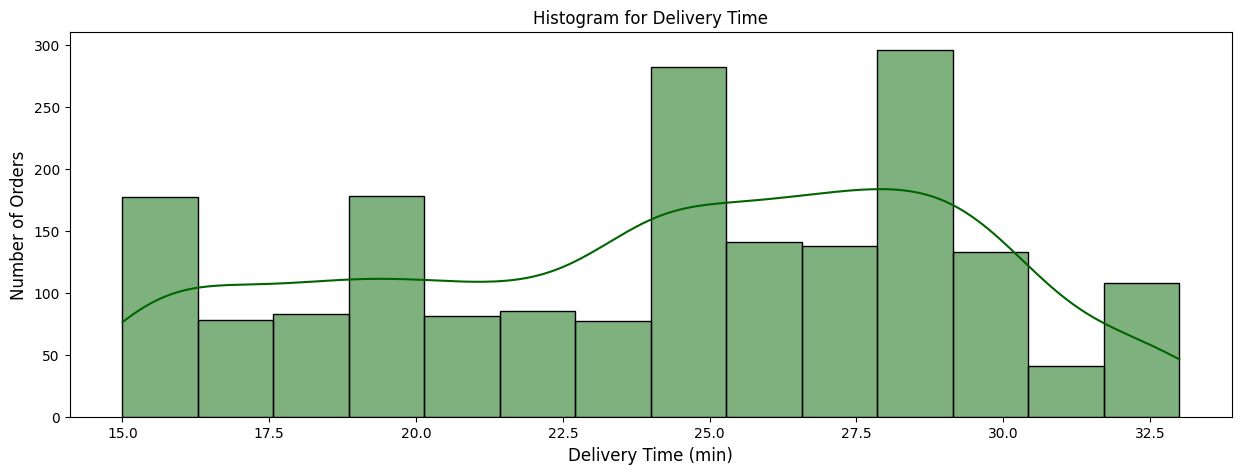

In [ ]:
# Check the trend of Delivery time using the Histogram to get more insight
plt.figure(figsize=(15,5));
sns.histplot(data=df,x='delivery_time', kde=True, color='darkgreen');
plt.title('Histogram for Delivery Time')
plt.xlabel('Delivery Time (min)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()

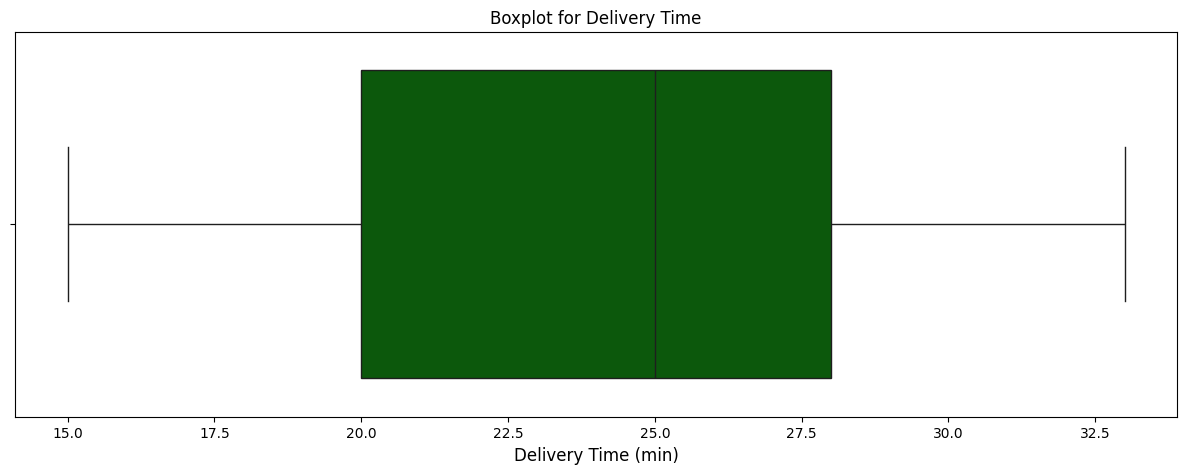

In [ ]:
# Let us see the Box plot for Delivery time
plt.figure(figsize=(15,5));
sns.boxplot(data=df,x='delivery_time', color='darkgreen')
plt.title('Boxplot for Delivery Time')
plt.xlabel('Delivery Time (min)', fontsize=12)
plt.show()

##### Observations:
* The plots show the minimum time taken to deliver the food is between 15 minutes while the maximum is 33 minutes, which is still good enough to maintain positive customer rating. .
* The box plot shows no outliers leading to the conclusion that Traffic Situation and overall transportation in the city is well streamlined and smooth.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Calculate top 5 restaurants in terms of the number of orders received using
# value_counts and head function
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

Below are the Top 5 Restaurants with respect to number of Orders:

1. Shake Shack                **219 Orders**
2. The Meatball Shop          **132 Orders**
3. Blue Ribbon Sushi          **119 Orders**
4. Blue Ribbon Fried Chicken  **96 Orders**
5. Parm                       **68 Orders**

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Create new dataframe with only weekends
df_weekend = df[df['day_of_the_week'] == 'Weekend']

In [ ]:
# Calculate top Cuisine in terms of the number of orders received using
# value_counts and head function
df_weekend['cuisine_type'].value_counts().head()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


#### Observations:
The Most popular cuisine on weekends is **American** Cuisine with a total **415** Orders received.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Creating new dataframe with Orders worth price more than 20 dollar
df_20 = df[df['cost_of_the_order'] > 20]
df_20

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,rating_original
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,Not given
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,3
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3.0,20,24,3
12,1476966,129969,Blue Ribbon Fried Chicken,American,24.30,Weekend,5.0,23,17,5
17,1477373,139885,Blue Ribbon Sushi Izakaya,Japanese,33.03,Weekend,NaN,21,22,Not given
...,...,...,...,...,...,...,...,...,...,...
1884,1477437,304993,Shake Shack,American,31.43,Weekend,3.0,31,24,3
1885,1477550,97324,Shake Shack,American,29.05,Weekday,4.0,27,29,4
1892,1477473,97838,Han Dynasty,Chinese,29.15,Weekend,NaN,29,21,Not given
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5.0,31,17,5


In [ ]:
# Print the total number of orders
print("Total number of orders:", len(df))

# Print the total number of orders above 20 dollars
print("Total number of orders above 20 dollars:", len(df_20))

# Calculate the percentage by dividing the count of df_20 with main dataset df
percentage = (len(df_20) / len(df)) * 100

# Print the percentage
print(f"The percentage of orders costing more than 20 dollars is: {percentage:.2f}%")

Total number of orders: 1898
Total number of orders above 20 dollars: 555
The percentage of orders costing more than 20 dollars is: 29.24%


#### Observations:
Out of total 1898 Orders, **555 Orders cost more than 20 dollars** which is **29.24%**

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Check the Statistical analysis for Delivery time
df['delivery_time'].describe().T

,delivery_time
count,1898.000000
mean,24.161749
std,4.972637
min,15.000000
25%,20.000000
50%,25.000000
75%,28.000000
max,33.000000


#### Observations:
The **Mean Order Delivery** Time is **24.162 minutes**

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Top 3 Customer IDs with most orders
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The **top 3** most regular customers are the ones with Customer IDs **52832**, **47440** and **83287**

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### Relationship Between Numerical Variables using Correlation (Heat) Map

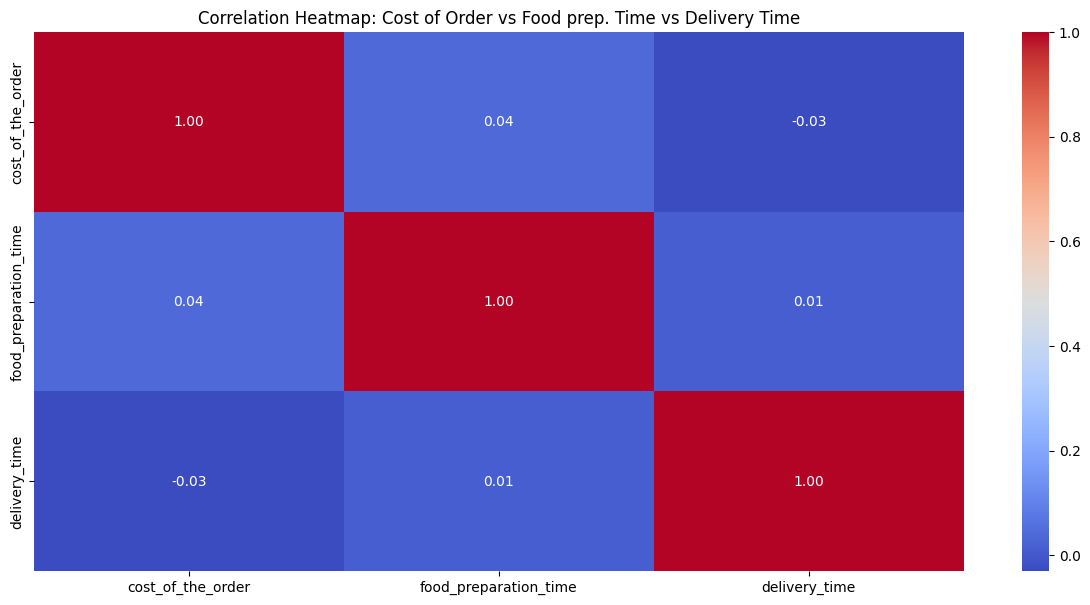

In [ ]:
# To check relationship between Numerical Variables we will be using
# Correlation (Heat) Map
plt.figure(figsize=(15,7));
numeric_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Cost of Order vs Food prep. Time vs Delivery Time')
plt.show()

###### Observations:
* The correlation matrix reveals that there is virtually no linear relationship between any of these variables.

    1. Cost vs. Preparation Time = 0.04
    2. Cost vs. Delivery Time = -0.03
    3. Preparation Time vs. Delivery Time = 0.01

* Insight: The price of an order does not affect how long it takes to prepare or deliver. Similarly, a longer preparation time does not correlate with a longer or shorter delivery time.

###### Recommendations:
* High priced orders are not getting any faster delivery, therefore a priority service for Expedited Preperation and Delivery may be introduced for customers placing high value orders.

#### Relationship Between Numerical & Catagorical Variables

##### 1. Cost of the Order vs. Top 5 Cuisine Types

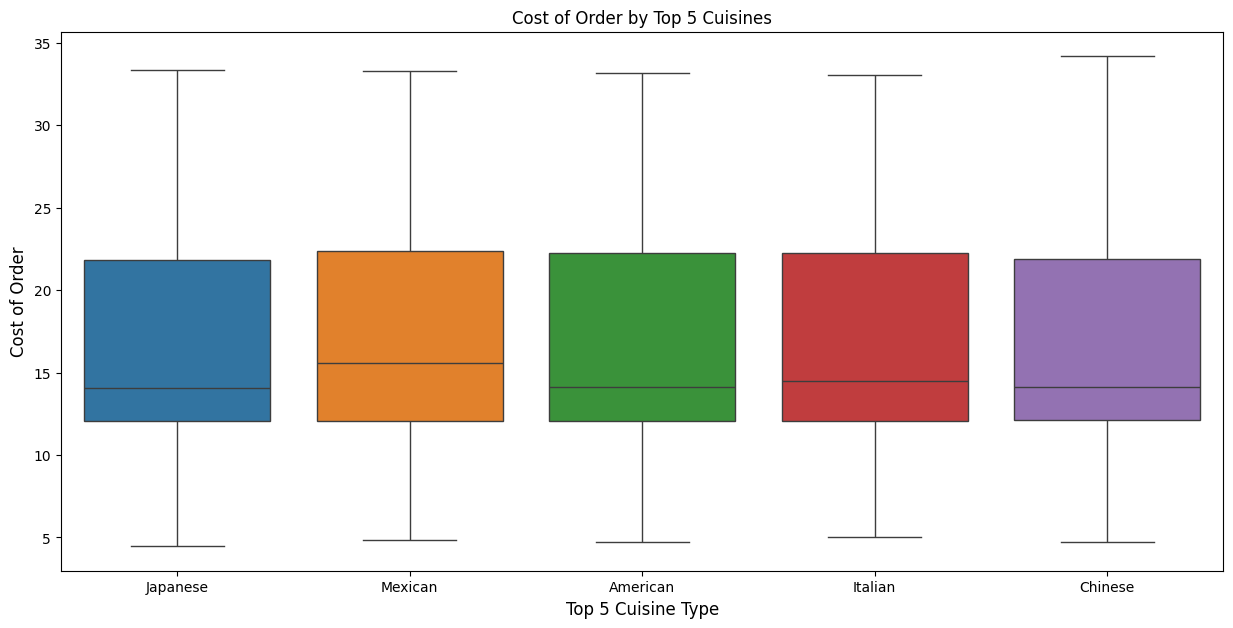

In [ ]:
# Identify the top 5 most frequent cuisines
top_5_cuisines = df['cuisine_type'].value_counts().nlargest(5).index

# Filter the dataframe for only these cuisines
df_top5 = df[df['cuisine_type'].isin(top_5_cuisines)]

plt.figure(figsize=(15,7));
sns.boxplot(data=df_top5, x='cuisine_type', y='cost_of_the_order', hue = 'cuisine_type');

# Define labels and layout for presentation
plt.title('Cost of Order by Top 5 Cuisines');
plt.xlabel('Top 5 Cuisine Type', fontsize=12)
plt.ylabel('Cost of Order', fontsize=12);
plt.show()

###### Observations:

* Among the top 5 most popular cuisines (American, Japanese, Italian, Chinese, and Mexican), the median cost of an order is quite consistent, generally hovering around the 14 dollars to 15 dollars mark.
* However, American and Japanese cuisines exhibit a slightly wider interquartile range.
* This suggests that while average meals cost the same, American and Japanese restaurants on the app offer a wider variety of premium options.

###### Recommendations:

* Treating all Japanese or American restaurants as single category is sub-optimal. We may target budget-conscious users with casual options and high-spending users with premium options e.g. *Budget_Japanese, Premium_Japanese*

##### 2. Cuisine vs Food Preparation time

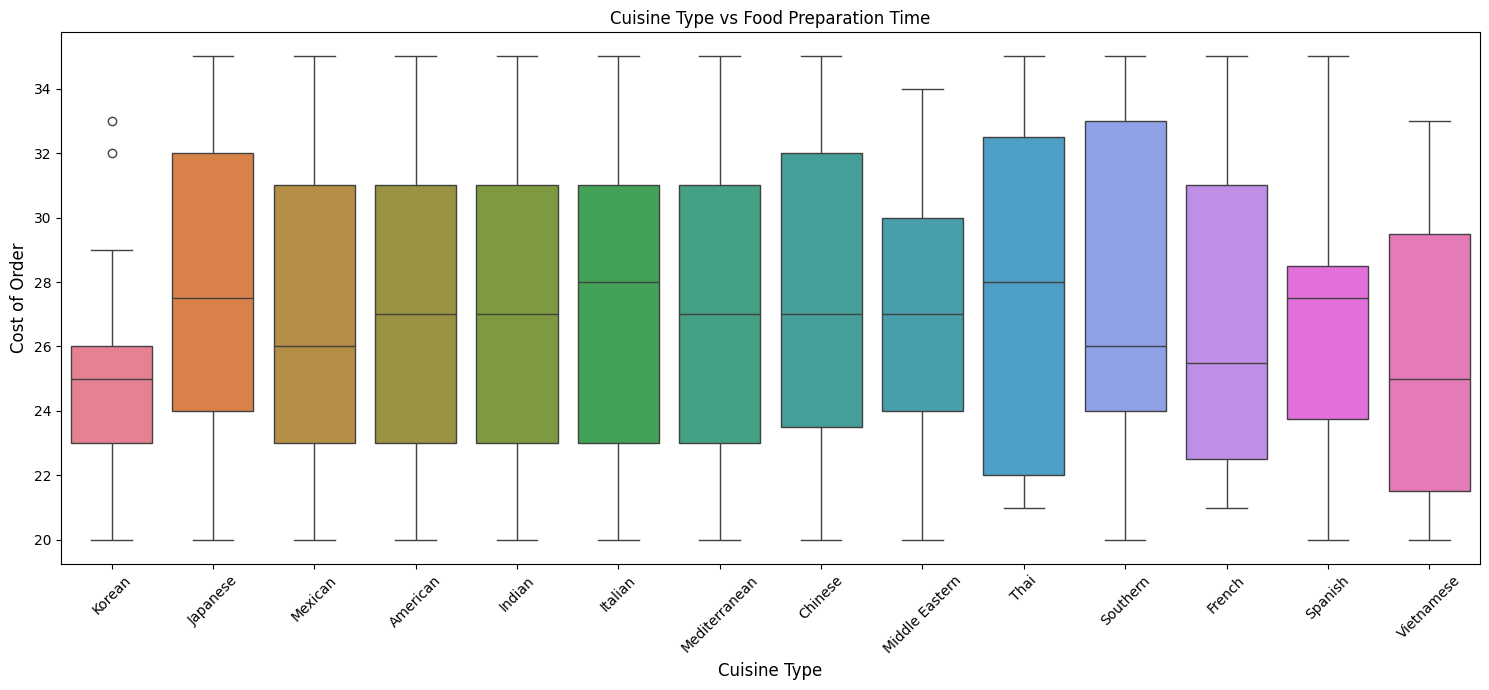

In [ ]:
# Identify the relationship between Cuisine and Food Preparation Time

plt.figure(figsize=(15,7));
sns.boxplot(data=df, x='cuisine_type', y='food_preparation_time', hue = "cuisine_type")

# Define labels and layout for presentation
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Food Preparation Time')
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Cost of Order', fontsize=12);
plt.tight_layout()
plt.show()

###### Observations:

* The average food preparation time (median) are almost similar across all cuisine types, generally hovering between 26 and 28 minutes.
* Korean and Vietnamese cuisines show a very slight edge in speed of preparation.
* Southern and Thai cuisines take slightly more time to prepare.

###### Recommendations:

* Cuisine type has very small variance in relation to preparation time, therefore it may not be significant for predicting Food preparation time based on the type of cuisine.

##### 3. Day of the Week vs Delivery time

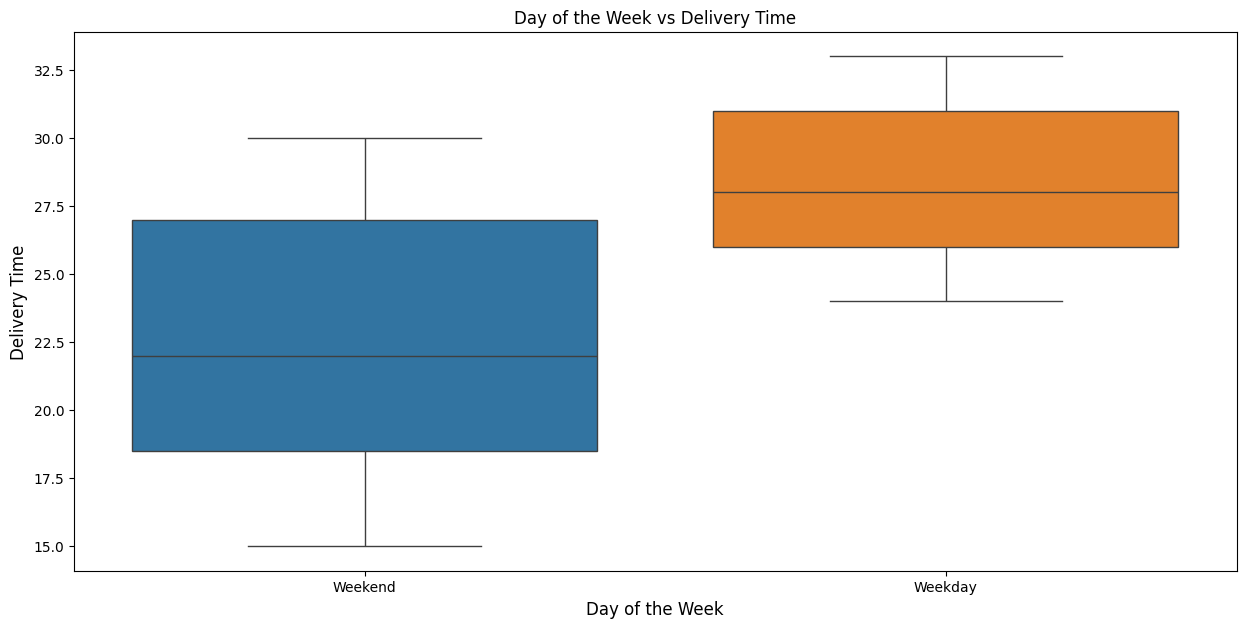

In [ ]:
# Identify the relationship between Day of the Week and Delivery time

plt.figure(figsize=(15,7));
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time', hue='day_of_the_week')

# Define labels and layout for presentation
plt.title('Day of the Week vs Delivery Time')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Delivery Time', fontsize=12);
plt.show()

###### Observations:

* There is a stark contrast in delivery times based on the day.
* Orders placed on weekdays have a significantly higher median delivery time (~28 minutes) and a tighter range (24 to 33 minutes) compared to weekends, which have a median delivery time of 22 minutes and a wider range (15 to 30 minutes).

###### Recommendations:

* We can face a logistics & supply chain issues on weekdays, due to a combination of traffic rush and fewer number of drivers compared to the weekend.
* We should incentivize drivers on weekdays peak hours to boost driver supply and reduce delivery times.

##### 4. Rating vs Delivery time with Day of the week

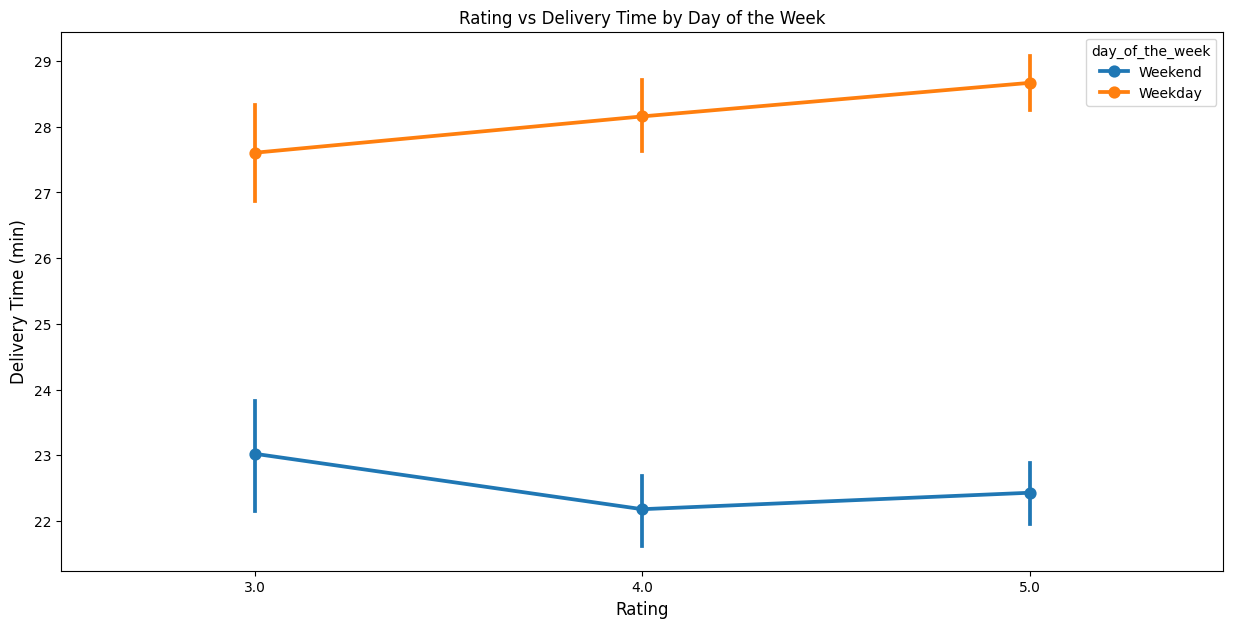

In [ ]:
# Identify the relationship between Rating and Delivery time by Day of the Week

plt.figure(figsize=(15,7));
sns.pointplot(data = df, x = 'rating', y = 'delivery_time', hue = 'day_of_the_week')

# Define labels and layout for presentation
plt.title('Rating vs Delivery Time by Day of the Week')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Delivery Time (min)', fontsize=12);
plt.show()

###### Observations:

* The pointplot shows a significant and consistent vertical gap (roughly 5–6 minutes) between Weekday and Weekend delivery times across all rating levels. Weekday deliveries are consistently slower.

* Both lines are relatively horizontal, indicating that as ratings move from 3 to 5, the delivery time does not decrease.

* This suggests that customers are just as satisfied with a ~28-minute delivery on a Weekday as they are with a ~22-minute delivery on a Weekend.


###### Recommendations:
* Since 5-star ratings are achieved on weekdays even with 28-minute averages, the business focus should be on factors other than Speed.

##### 5. Rating vs Food preparation time

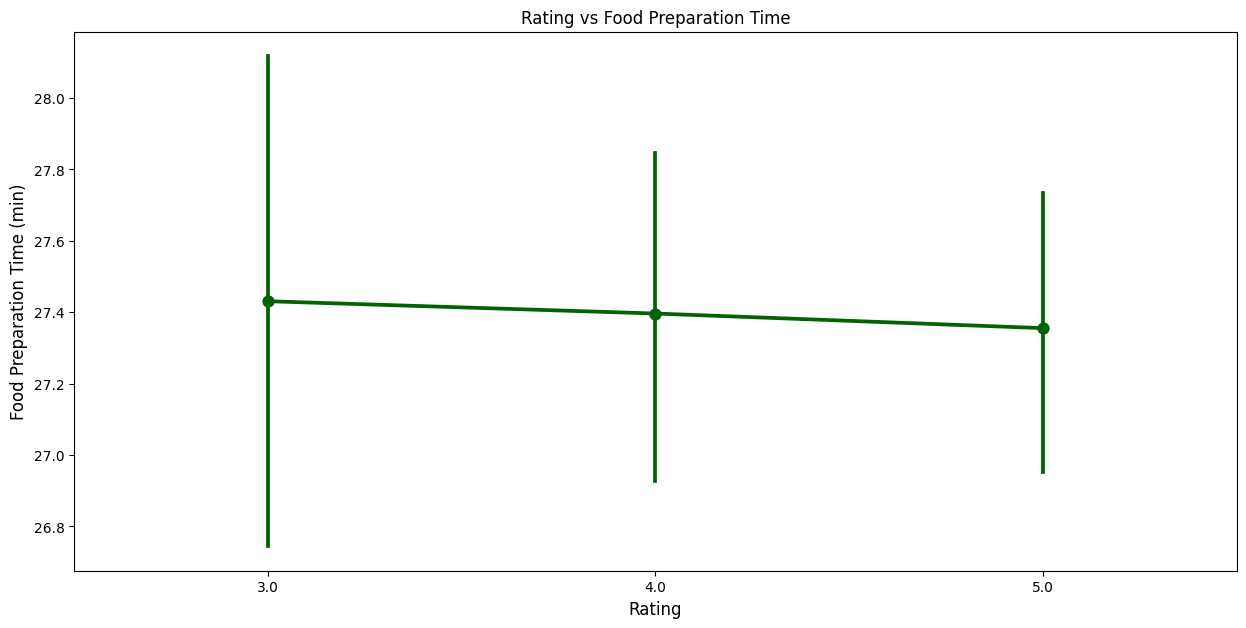

In [ ]:
# Identify the relationship between Rating and Food Preparation Time

plt.figure(figsize=(15,7));
sns.pointplot(data = df, x = 'rating', y = 'food_preparation_time', color='darkgreen');

# Define labels and layout for presentation
plt.title('Rating vs Food Preparation Time')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Food Preparation Time (min)', fontsize=12);
plt.show()

###### Observations:
* Similar to delivery time, the food preparation times are completely uniformly distributed across all rating categories.
* The average prep time for a 3-star review (27.45 mins) is virtually the same as a 5-star review (27.35 mins).

###### Recommendations:
* Slower food preparation does not cause lower ratings.
* Customers understand that good food takes time to prepare.
* Foodhub should not pressure restaurant partners to rush food preparation to improve app ratings, as this could inadvertently lower food quality (which eventually will impact rating)

##### 6. Restaurant Name vs Cost of the Order

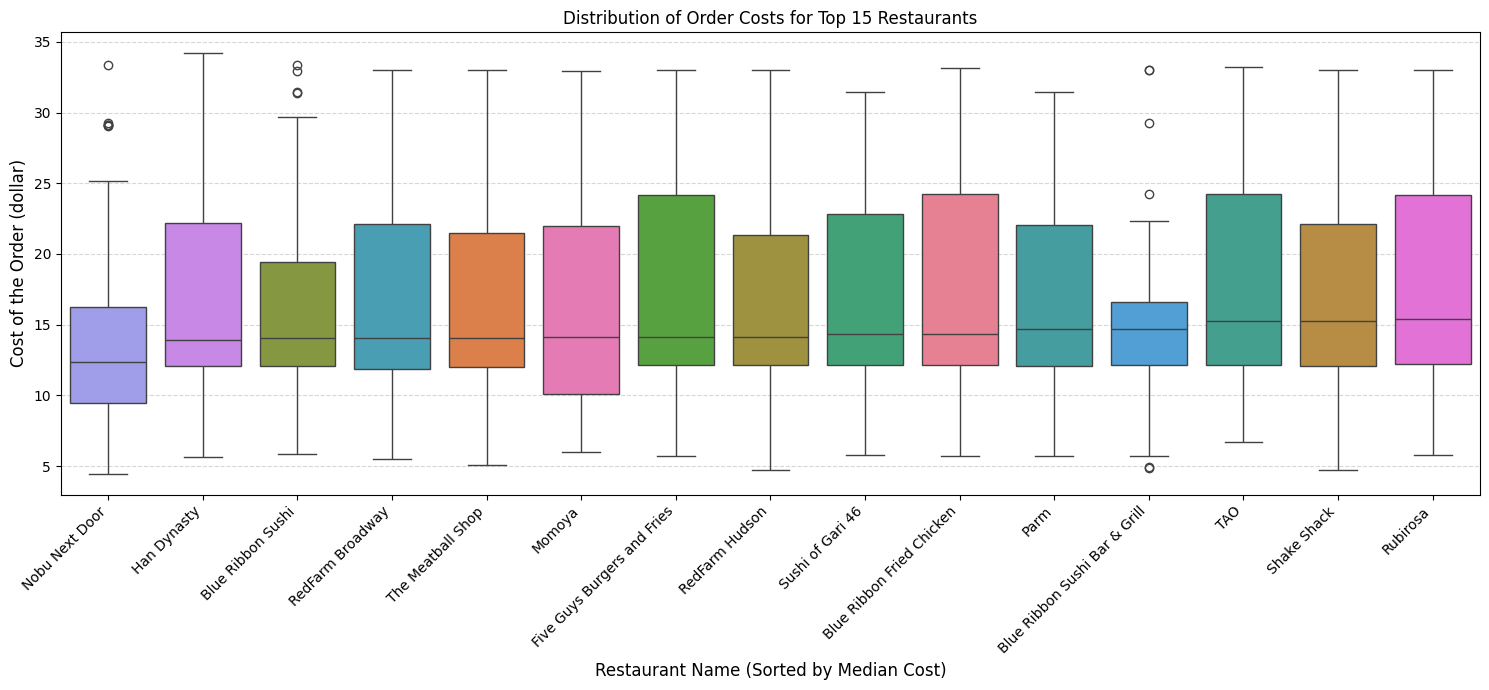

In [ ]:
# Filter for the top 15 most popular restaurants
top_15_rests = df['restaurant_name'].value_counts().nlargest(15).index
df_top15 = df[df['restaurant_name'].isin(top_15_rests)].copy()

# Sort the order of the boxplots by the median cost of each restaurant
sorted_order = df_top15.groupby('restaurant_name')['cost_of_the_order'].median().sort_values().index

plt.figure(figsize=(15, 7))
sns.boxplot(data=df_top15, x='restaurant_name', y='cost_of_the_order', order=sorted_order, hue='restaurant_name')

# Define labels and layout for presentation
plt.xticks(rotation=45, ha='right')
plt.xlabel('Restaurant Name (Sorted by Median Cost)', fontsize=12)
plt.ylabel('Cost of the Order (dollar)', fontsize=12);
plt.title('Distribution of Order Costs for Top 15 Restaurants');
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###### Observations:

* By sorting the restaurants, we can see a clear hierarchy. Nobu Next Door consistently facilitates the lowest-priced median orders (12.35 dollars), while Rubirosa sits at the top (15.38 dollars).

* Restaurants like Parm and The Meatball Shop show very tight interquartile ranges (IQRs), indicating highly predictable customer spending patterns. Conversely, Shake Shack and Blue Ribbon Sushi show a massive spread in order costs and several high-value outliers (above 30 dollars).

* This suggests these platforms are used for both small solo meals and large group/family orders.

* Outlier Prevalence: High-cost outliers are prominent in nearly all top restaurants, signifying that while typical orders are around 15 dollars, there is a significant tail of high-value transactions that drive total revenue.

###### Recommendations:
* Since restaurants with high variance indicate group order potential, the marketing team can target these specific restaurants with Family Meal promotions during weekends to capitalize on the existing trend of high-value outliers.

#### Rating vs Cost of the order

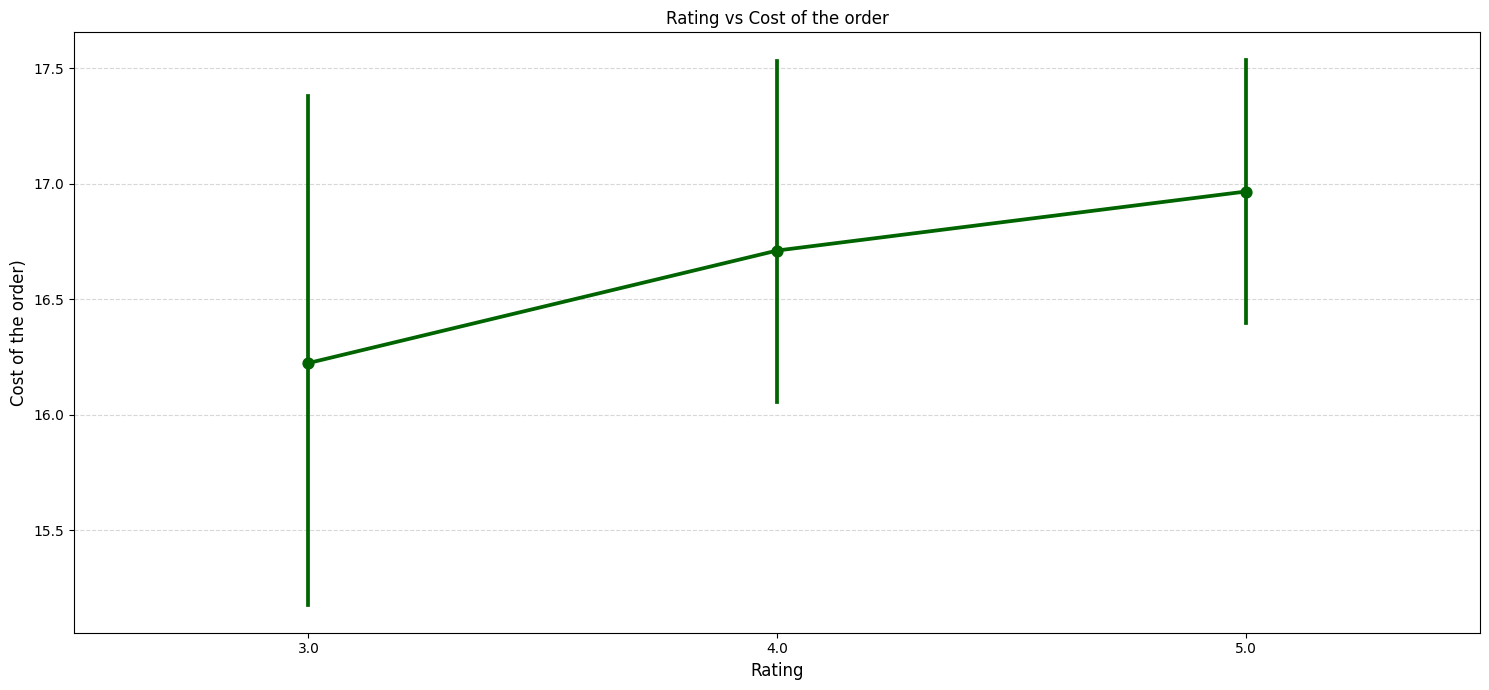

In [ ]:
# Identify the relationship between Rating and Cost of the order

plt.figure(figsize=(15,7));
sns.pointplot(data = df, x = 'rating', y = 'cost_of_the_order', color='darkgreen');

# Define labels and layout for presentation
plt.title('Rating vs Cost of the order')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Cost of the order)', fontsize=12);
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###### Observations:

* The pointplot reveals a subtle but observable positive relationship between the cost of the order and the rating. The mean cost increases from 16.22 dollar for a 3-star rating to 16.97 dollars for a 5-star rating.

* The error bars show some overlap between the 4-star and 5-star ratings, but the mean for 3-star ratings is notably lower. This suggests that while cost isn't the sole driver of satisfaction, higher-rated orders tend to be slightly more expensive on average.

* This could indicate that customers who spend more are ordering from higher-quality restaurants or are more paying for the meal, potentially leading to higher satisfaction if the quality matches the price.

###### Recommendations:
* Since restaurants with high variance indicate group order potential, the marketing team can target these specific restaurants with Family Meal promotions during weekends to capitalize on the existing trend of high-value outliers.

#### Run the below code and write your observations on the revenue generated by the restaurants.

In [ ]:
top_revenue_restaurants = df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14)
top_revenue_restaurants

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


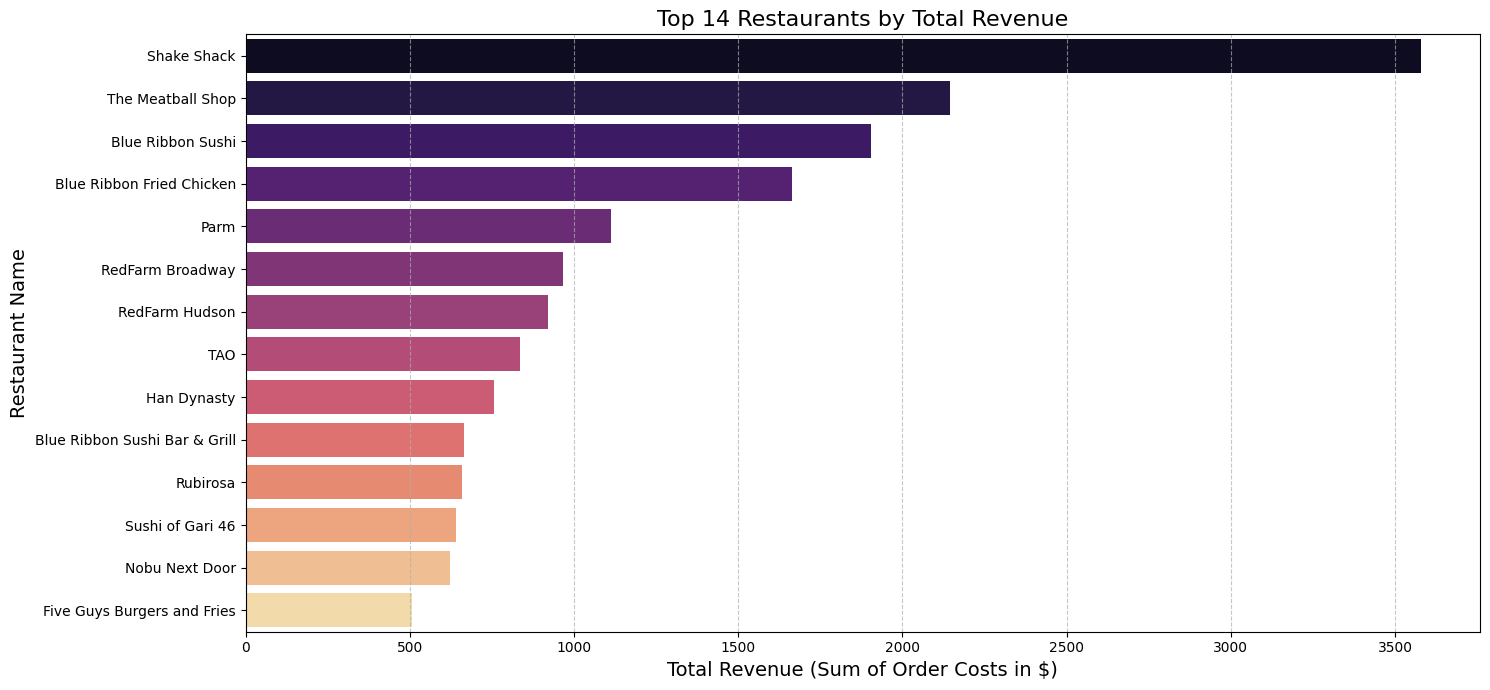

In [ ]:
# suppressing the warnings for depricated libraries
import warnings
warnings.filterwarnings('ignore')

# Visualize the top 14 revenue earners
plt.figure(figsize=(15, 7))
sns.barplot(x=top_revenue_restaurants.values, y=top_revenue_restaurants.index, palette='magma')
plt.title('Top 14 Restaurants by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue (Sum of Order Costs in $)', fontsize=14)
plt.ylabel('Restaurant Name', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

###### Observations:

* Shake Shack is significantly outperforming all other partners, generating a total revenue of **3,579.53 dollars**. It is nearly 67% higher than the next highest earner, The Meatball Shop (2,145.21 dollars).

* A significant portion of the total platform revenue is concentrated in the top 4-5 restaurants (Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken). These "anchor" restaurants are likely the primary drivers of user traffic and repeat business.

* There is a steep drop-off after the top 5. While the first few restaurants cross the $1,500+ mark, the bottom half of the top 14 (like Nobu Next Door and Five Guys) earns significantly less, hovering between 500 dollar and 650 dollar in total revenue.

* Various Blue Ribbon branded locations (Sushi, Fried Chicken, and Sushi Bar & Grill) all appear in the top 14, collectively contributing a massive share of the platform's revenue.

* Since revenue is highly concentrated, losing any of the top 5 restaurant partners would represent a major financial blow to the platform. The business team should identify Risk for these specific partners and potentially offer them reduced commission rates or exclusive marketing offers to secure long-term contracts.

* For users who frequently order from the high-revenue restaurants should be recommended in a collaborative way to cross-sell them to lower revenue restaurants to diversify revenue stream.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# 1. Filter the rated restaurants (ignoring 'Not given')
df_rated = df[df['rating_original'] != 'Not given'].copy()

# 2. Convert rating column from object to integer
df_rated['rating'] = df_rated['rating'].astype('int')

# 3. Create a dataframe that contains the restaurant names with their rating counts
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending=False).reset_index()

df_rating_count.head()


,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [ ]:
# 4. Get the restaurant names that have a rating count of more than 50
# The count results in a column named 'rating'
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']

# 5. Filter to get the data of restaurants that have a rating count of more than 50
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()

# 6. Group by restaurant name and find the mean rating
df_mean_4_rating = df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending=False).reset_index().dropna()

# 7. Filter for average rating greater than 4
# The mean results in a column named 'rating'
df_avg_rating_greater_than_4 = df_mean_4_rating[df_mean_4_rating['rating'] > 4].sort_values(by='rating', ascending=False).reset_index(drop=True)

# Final Result
print(df_avg_rating_greater_than_4)

             restaurant_name    rating
0          The Meatball Shop  4.511905
1  Blue Ribbon Fried Chicken  4.328125
2                Shake Shack  4.278195
3          Blue Ribbon Sushi  4.219178


##### Observations:

###### Qualified Restaurants for the Promotional Offer

1. The Meatball Shop
2. Blue Ribbon Fried Chicken
3. Shake Shack
4. Blue Ribbon Sushi

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Function to determine the company's commission revenue per order
def compute_rev(x):
    if x > 20:
        return x * 0.25 # 25% for orders above $20
    elif x > 5:
        return x * 0.15 # 15% for orders above $5
    else:
        return x * 0    # 0% for orders $5 or less

# Applying the function to the 'cost_of_the_order' column
df['Revenue'] = df['cost_of_the_order'].apply(compute_rev)

# Displaying the first few rows to verify the calculation
print(df[['order_id', 'cost_of_the_order', 'Revenue']].head())

# Getting the sum of the total company revenue across all orders
total_rev = df['Revenue'].sum()
print('The net revenue is around', round(total_rev, 2), 'dollars')

   order_id  cost_of_the_order  Revenue
0   1477147              30.75   7.6875
1   1477685              12.08   1.8120
2   1477070              12.23   1.8345
3   1477334              29.20   7.3000
4   1478249              11.59   1.7385
The net revenue is around 6166.3 dollars


#### Observations:

The net revenue generated by the company is around **6166.3 dollars**

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# 1. Calculate total delivery time and add a new column to the dataframe
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# 2. Count the number of orders that take more than 60 minutes
orders_over_60 = df[df['total_time'] > 60].shape[0]

# 3. Calculate the percentage of orders relative to the total number of orders
total_orders = df.shape[0]
percentage_over_60 = (orders_over_60 / total_orders) * 100

print('The percentage of orders taking more than 60 minutes is around', round(percentage_over_60, 2), '%')

The percentage of orders taking more than 60 minutes is around 10.54 %


#### Observations:

The percentage of orders taking more than 60 minutes is around **10.54%**


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# 1. Get the mean delivery time on weekdays and print it
print('The mean delivery time on weekdays is around',
      round(df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()),
      'minutes')

# 2. Get the mean delivery time on weekends and print it
print('The mean delivery time on weekends is around',
      round(df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()),
      'minutes')

The mean delivery time on weekdays is around 28 minutes
The mean delivery time on weekends is around 22 minutes


#### Observations:

*   The mean delivery time on **weekdays** is around **28 minutes**
*   The mean delivery time on **weekends** is around **22 minutes**



#### Conclusion

* There is a notable 6-minute (approx. 21%) difference in average delivery times between weekdays and weekends. Weekends are substantially faster.

* Almost all deliveries fall between 24 and 33 minutes

* There are significantly more orders on the weekends (1,351) than on weekdays (547), yet the system performs faster during high-volume periods.

* The delivery network is currently struggling with weekday latency

#### Recommendations

* The company should implement a "Weekday Bonus" or surge pricing for couriers during weekday lunch and dinner peaks. Increasing driver density on weekdays is the most likely way to close the 6-minute gap.

* Since delivery is faster on weekends, marketing campaigns should highlight "Flash Delivery Weekends" to further capitalize on existing operational strengths and drive even higher volumes when the system is at its most efficient

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

*  The platform suffers from a severe logistical imbalance. Despite having fewer orders on weekdays, the average delivery time is significantly higher (28 minutes) compared to weekends (22 minutes). Furthermore, over 10.5% of all orders take more than 60 minutes from placement to delivery, risking high customer churn _(losing customer base)_.

* The platform's revenue is heavily concentrated. A small handful of restaurants (predominantly Shake Shack, The Meatball Shop, and the Blue Ribbon franchise) generate a massive portion of the total order volume and commission revenue.

* Surprisingly, customer ratings (3, 4, or 5 stars) show almost no correlation with the cost of the order, food preparation time, or delivery time. This suggests customers rate based on food quality, accuracy, and whether the ETA was met, rather than the just speed or price.


### Recommendations:

#### Recommendations for Cuisine Type

* Capitalize on Top Cuisines: American, Japanese, and Italian are by far the most dominant cuisines in terms of order volume and revenue generation.
    
  * Action item: The sales/marketing team should prioritize onboarding more high-quality restaurants in these specific categories.
        
* Cross-Selling: While American and Japanese dominate, cuisines like Korean and Vietnamese actually showed slightly faster average preparation times.
        
  * Action item: Promote these fast-prep, cuisines to users who normally order American food during weekdays. This will provide users with faster options in rush office hours.

#### Recommendations based on Ratings

  * Incentivize Rating Submissions: A large portion of the dataset had ratings listed as "Not given."
    
    * Action: Implement a post-order incentive (e.g., "$1 off your next order for rating your last meal").
        
  * Promote Premium Tier: Only four restaurants (The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, Blue Ribbon Sushi) achieved both high volume (>50 ratings) and high satisfaction (>4.0 average).
    
    * Action: Create a "Top Rated" badge on the app's homepage for these restaurants. Use their operational metrics (e.g., how they handle packaging and prep times) as a benchmark to coach lower-performing restaurants.
        
        
#### Recommendations driven by Delivery Time

* Solve the Weekday Delay: The 6-minute lag on weekday deliveries is a critical vulnerability.
    
  * Action Item: Implement Driver Incentives during weekday peak hours (e.g., lunch rush) to increase the supply of drivers and reduce dispatch delays.
        
* 60 min Outliers: 10.5% of orders take over an hour, these are our highest churn-risk events.
    
  * Action Item: Build a real-time monitoring system i.e. dashboard for drivers. If an order hits the 40-minute mark and hasn't been picked up by a courier, automatically escalation is done to panalize.
        
#### Financial Recommendations

* 25% Commission Tier: The company makes significantly more margin on orders over 20 dollars.
    
  * Action Item: Implement a feature in the app that says "Add X dollars to your order to unlock free delivery.
        
* Minimum Order Policy: Orders under 5 dollars do not yielf any commission for the company, effectively making them a loss.
    
  * Action Item: Enforce a "Small Order Fee" for baskets under 5 dollars, or work with restaurants to set a 5 dollar minimum for delivery.

---